# Diabetes Risk Prediction - Model Training

**Dataset:** PIMA Indians Diabetes Database  
**Source:** UCI Machine Learning Repository / Kaggle  
**Target:** Predict whether a patient has diabetes (binary: 0 = No, 1 = Yes)

## Notebook Outline

1. Setup and imports.
2. Loading Dataset.
3. Data cleaning and preprocessing.
4. Exploratory Data Analysis (EDA).
5. Visualization.
6. Feature engineering.
7. Model training using Logistic Regression, Random Forest and XGBoost.
8. Model evaluation and comparison.
9. Save best model with joblib.

## 1. Setup and Imports :

In [79]:
# Importing required libraries.
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi':       120,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
})
from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing    import StandardScaler
from sklearn.calibration      import calibration_curve
from sklearn.pipeline         import Pipeline
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (
    accuracy_score, classification_report,
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import joblib
print('All libraries loaded.')

All libraries loaded.


## 2. Dataset Loading

In [80]:
# Load the PIMA Indians Diabetes Datset in CSV.

DATA_PATH = 'diabetes.csv'
df = pd.read_csv(DATA_PATH)
print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nColumn names:')
for col in df.columns:
    print(f' {col}')
df.head()

Dataset loaded: 768 rows × 9 columns

Column names:
 Pregnancies
 Glucose
 BloodPressure
 SkinThickness
 Insulin
 BMI
 DiabetesPedigreeFunction
 Age
 Outcome


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [81]:
# Basic info — dtypes, null counts
print('Dataset info:')
df.info()
print()
print('Descriptive statistics:')
df.describe().round(2)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Descriptive statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [82]:
# Class distribution
counts = df['Outcome'].value_counts()
print('Target class distribution:')
print(f'  0 (No Diabetes): {counts[0]} ({counts[0]/len(df)*100:.1f}%)')
print(f'  1 (Diabetes):    {counts[1]} ({counts[1]/len(df)*100:.1f}%)')

Target class distribution:
  0 (No Diabetes): 500 (65.1%)
  1 (Diabetes):    268 (34.9%)


## 3. Data Cleaning and Preprocessing

In [83]:
# Replace biologically impossible zeros with NaN (imputation will happen after split)

ZERO_AS_MISSING = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_clean = df.copy()

for col in ZERO_AS_MISSING:
    zero_count = (df_clean[col] == 0).sum()
    df_clean[col] = df_clean[col].replace(0, np.nan)
    print(f'{col:25s} zeros replaced with NaN: {zero_count}')

print('\nCleaning complete ')
print(f'Remaining nulls: {df_clean.isnull().sum().sum()}')

Glucose                   zeros replaced with NaN: 5
BloodPressure             zeros replaced with NaN: 35
SkinThickness             zeros replaced with NaN: 227
Insulin                   zeros replaced with NaN: 374
BMI                       zeros replaced with NaN: 11

Cleaning complete 
Remaining nulls: 652


In [84]:
# Train/Test split 
# We use stratified splitting to preserve the class ratio in both sets.
# 80% train, 20% test standard for this dataset size (768 samples).

FEATURE_COLS = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]
TARGET_COL = 'Outcome'

X = df_clean[FEATURE_COLS]
y = df_clean[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Train set: {X_train.shape[0]} samples')
print(f'Test  set: {X_test.shape[0]} samples')
print(f'Features:  {X_train.shape[1]}')

Train set: 614 samples
Test  set: 154 samples
Features:  8


In [85]:
# Median imputation using training data only (prevents data leakage)

train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("Missing values filled using training medians.")

Missing values filled using training medians.


## 4. Exploratory Data Analysis (EDA)

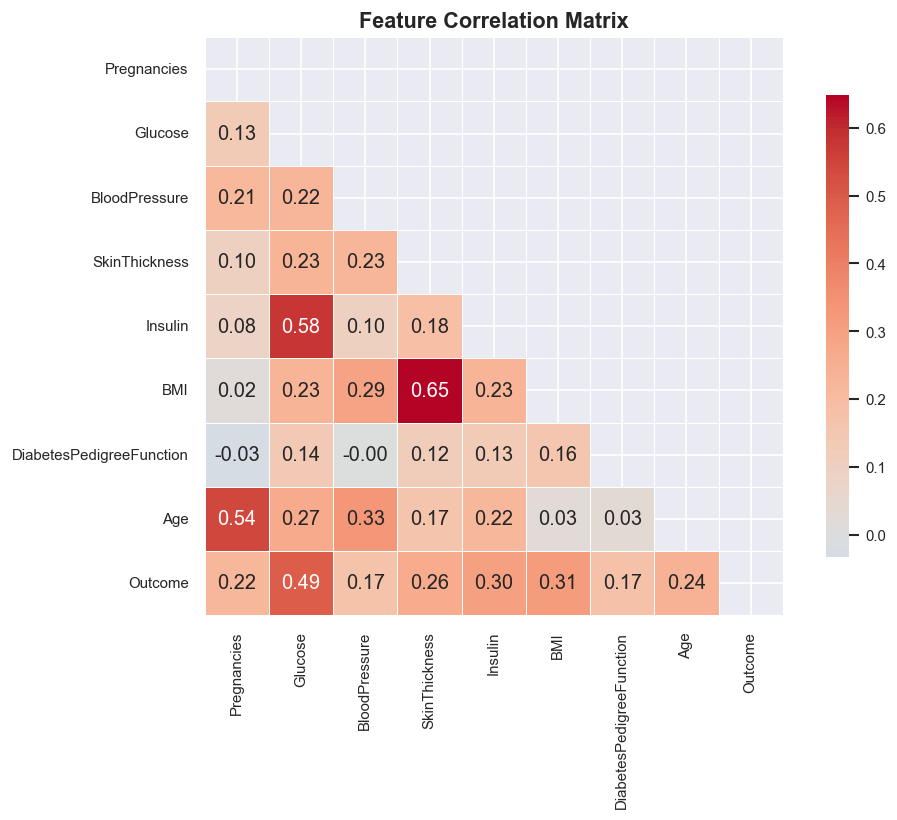


Correlations with Outcome (sorted):
Glucose                     0.495
BMI                         0.314
Insulin                     0.303
SkinThickness               0.259
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
BloodPressure               0.171


In [86]:
#Correlation matrix :
fig, ax = plt.subplots(figsize=(9, 7))

corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    ax=ax,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with Outcome
print('\nCorrelations with Outcome (sorted):')
print(corr['Outcome'].drop('Outcome').sort_values(ascending=False).round(3).to_string())

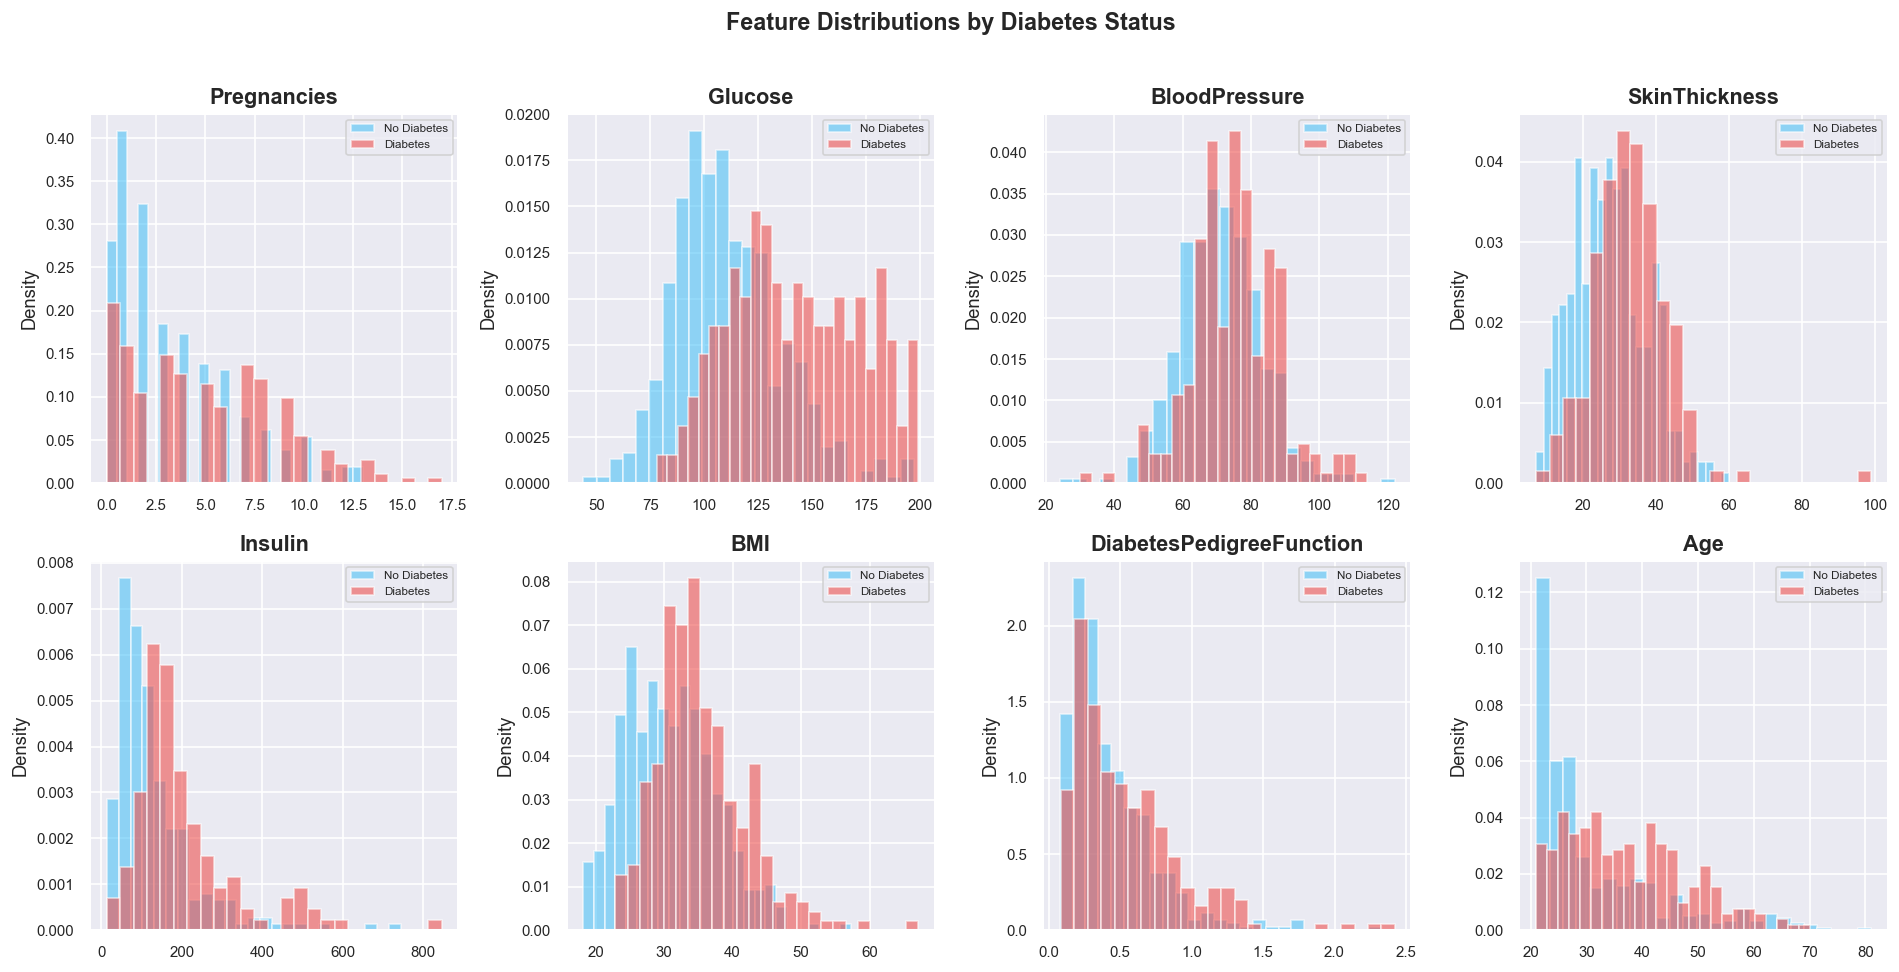

In [87]:
# Feature distributions split by Outcome :
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

palette = {0: '#4fc3f7', 1: '#ef5350'}  # blue = no diabetes, red = diabetes

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    for outcome, label in [(0, 'No Diabetes'), (1, 'Diabetes')]:
        subset = df_clean[df_clean['Outcome'] == outcome][col]
        ax.hist(
            subset,
            bins=25,
            alpha=0.6,
            color=palette[outcome],
            label=label,
            density=True
        )
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_xlabel('')
    ax.set_ylabel('Density')

plt.suptitle('Feature Distributions by Diabetes Status', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

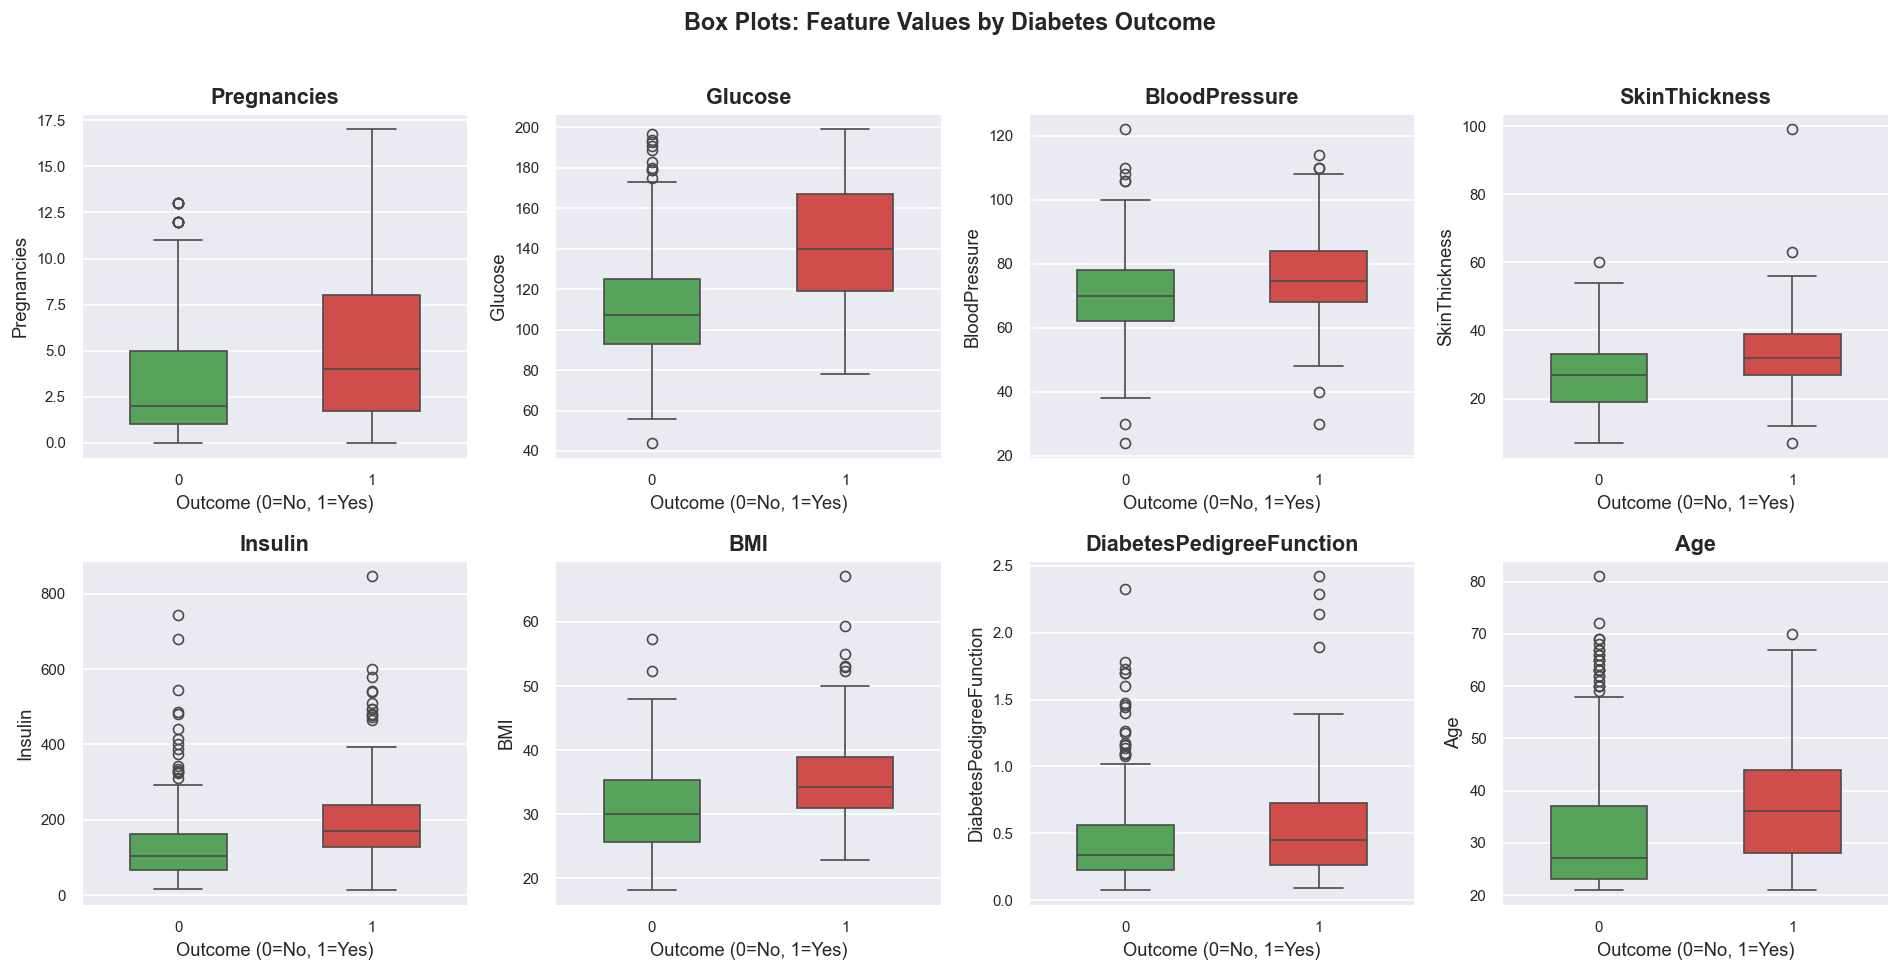

In [88]:
# Box plots per feature
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
palette = {0: "#4CAF50", 1: "#E53935"}  # Green = No Diabetes, Red = Diabetes
for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    sns.boxplot(
        data=df_clean,
        x='Outcome',
        y=col,
        hue='Outcome', 
        palette=palette,
        ax=ax,
        width=0.5,
        legend=False 
    )
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Outcome (0=No, 1=Yes)')
    ax.set_ylabel(col)

plt.suptitle('Box Plots: Feature Values by Diabetes Outcome', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

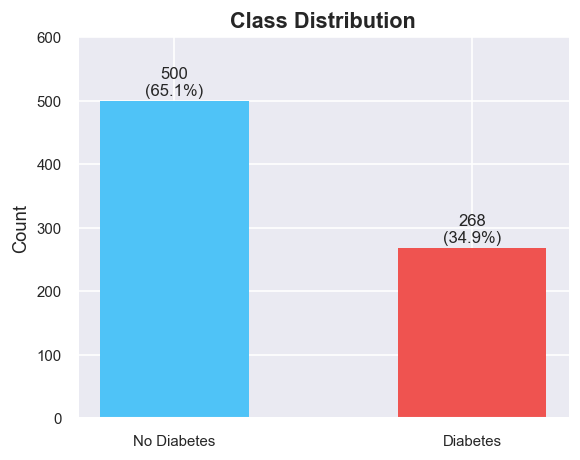

In [89]:
# Outcome class bar chart :
fig, ax = plt.subplots(figsize=(5, 4))
counts = df_clean['Outcome'].value_counts()
bars = ax.bar(
    ['No Diabetes', 'Diabetes'],
    counts.values,
    color=['#4fc3f7', '#ef5350'],
    edgecolor='none',
    width=0.5
)
for bar, count in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 4,
        f'{count}\n({count/len(df_clean)*100:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )
ax.set_title('Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

## 5. Model Training

We train three classifiers inside scikit-learn 'Pipeline' objects.
Wrapping in a Pipeline ensures the scaler is fit only on training data,
preventing data leakage.

In [90]:
# Model 1: Logistic Regression:
lr_pipeline = Pipeline([
    ('scaler',     StandardScaler()),
    ('classifier', LogisticRegression(
        max_iter=1000,
        C=1.0,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)
lr_preds  = lr_pipeline.predict(X_test)
lr_probas = lr_pipeline.predict_proba(X_test)[:, 1]

lr_acc = accuracy_score(y_test, lr_preds)
lr_auc = roc_auc_score(y_test, lr_probas)

print(f'Logistic Regression:')
print(f'  Accuracy : {lr_acc:.4f}')
print(f'  AUC-ROC  : {lr_auc:.4f}')
print()
print(classification_report(y_test, lr_preds, target_names=['No Diabetes', 'Diabetes']))

Logistic Regression:
  Accuracy : 0.7078
  AUC-ROC  : 0.8130

              precision    recall  f1-score   support

 No Diabetes       0.75      0.82      0.78       100
    Diabetes       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [117]:
# Model 2: Random Forest :

rf_pipeline = Pipeline([
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
rf_preds  = rf_pipeline.predict(X_test)
rf_probas = rf_pipeline.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_probas)

print(f'Random Forest:')
print(f'  Accuracy : {rf_acc:.4f}')
print(f'  AUC-ROC  : {rf_auc:.4f}')
print()
print(classification_report(y_test, rf_preds, target_names=['No Diabetes', 'Diabetes']))

Random Forest:
  Accuracy : 0.7468
  AUC-ROC  : 0.8085

              precision    recall  f1-score   support

 No Diabetes       0.77      0.87      0.82       100
    Diabetes       0.68      0.52      0.59        54

    accuracy                           0.75       154
   macro avg       0.73      0.69      0.70       154
weighted avg       0.74      0.75      0.74       154



In [92]:
# Model 3: XGBoost :
# to handle the class imbalance (65/35 split).

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / pos  # compensates for more negative samples
print(f'scale_pos_weight = {scale_pos:.2f}  (neg={neg}, pos={pos})')

xgb_pipeline = Pipeline([
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)
xgb_preds  = xgb_pipeline.predict(X_test)
xgb_probas = xgb_pipeline.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_test, xgb_preds)
xgb_auc = roc_auc_score(y_test, xgb_probas)

print(f'\nXGBoost:')
print(f'  Accuracy : {xgb_acc:.4f}')
print(f'  AUC-ROC  : {xgb_auc:.4f}')
print()
print(classification_report(y_test, xgb_preds, target_names=['No Diabetes', 'Diabetes']))

scale_pos_weight = 1.87  (neg=400, pos=214)

XGBoost:
  Accuracy : 0.7597
  AUC-ROC  : 0.8331

              precision    recall  f1-score   support

 No Diabetes       0.84      0.78      0.81       100
    Diabetes       0.64      0.72      0.68        54

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.76      0.76       154



## 6. Model Evaluation and Comparison :

In [102]:
# 5-fold cross-validation comparison :
# Using the full cleaned dataset (X, y) for cross-validation.

# Fill missing values for cross-validation dataset
X_cv = X.fillna(X.median())

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = [
    ('Logistic Regression', lr_pipeline),
    ('Random Forest', rf_pipeline),
    ('XGBoost', xgb_pipeline),
]

print('5-Fold Cross-Validation Results :')
cv_results = {}

for name, model in models:
    scores = cross_val_score(model, X_cv, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s}  AUC: {scores.mean():.4f} +/- {scores.std():.4f}')

5-Fold Cross-Validation Results :
Logistic Regression        AUC: 0.8366 +/- 0.0204
Random Forest              AUC: 0.8400 +/- 0.0200
XGBoost                    AUC: 0.8245 +/- 0.0269


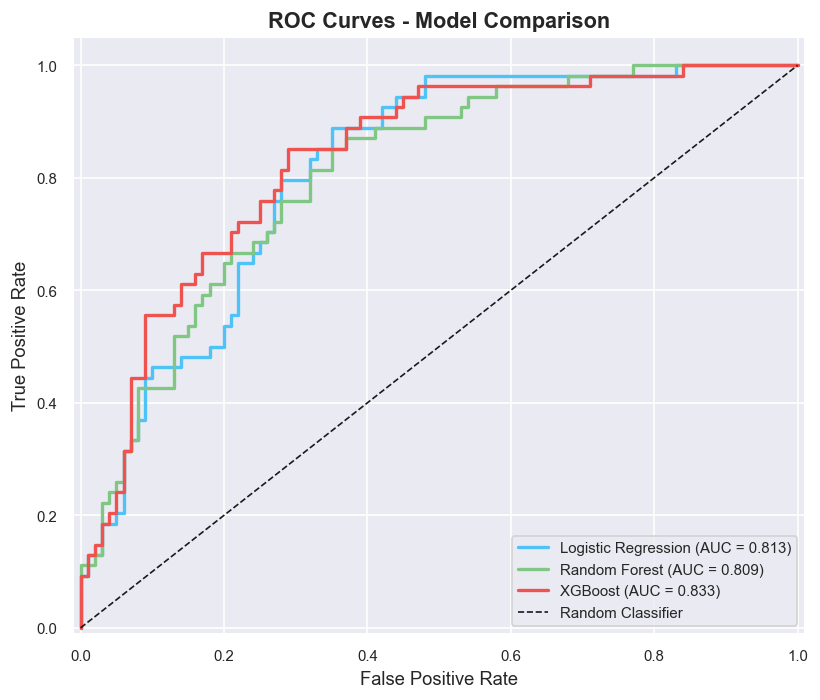

In [111]:
# ROC Curve comparison :
fig, ax = plt.subplots(figsize=(7, 6))

plot_data = [
    ('Logistic Regression', lr_probas,  lr_auc,  '#4fc3f7'),
    ('Random Forest',       rf_probas,  rf_auc,  '#81c784'),
    ('XGBoost',             xgb_probas, xgb_auc, '#ef5350'),
]

for name, probas, auc, color in plot_data:
    fpr, tpr, _ = roc_curve(y_test, probas)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Model Comparison', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])
plt.tight_layout()
plt.show()

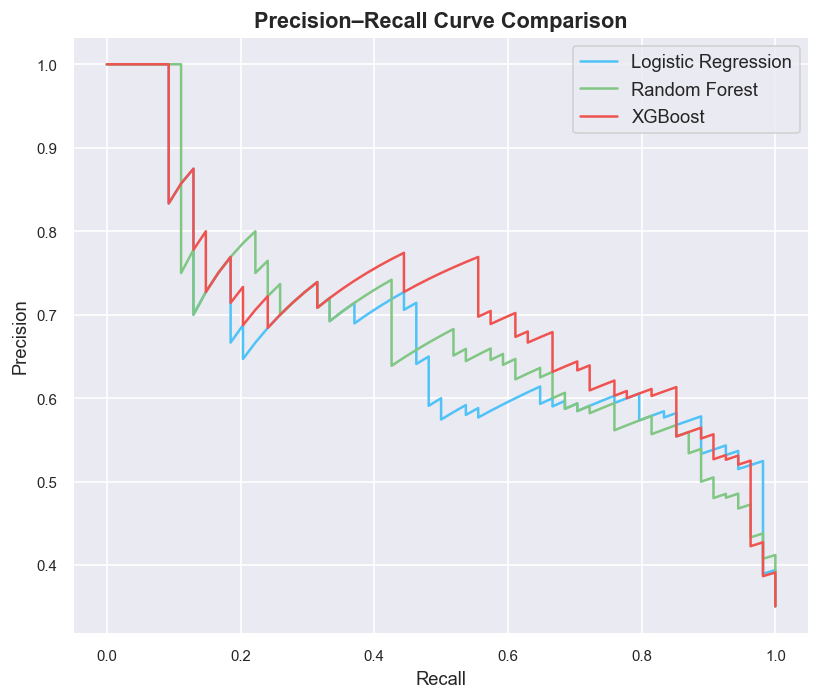

In [112]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(7,6))

models_pr = [
    ('Logistic Regression', lr_probas, '#4fc3f7'),
    ('Random Forest', rf_probas, '#81c784'),
    ('XGBoost', xgb_probas, '#ef5350')
]

for name, probas, color in models_pr:
    precision, recall, _ = precision_recall_curve(y_test, probas)
    ax.plot(recall, precision, label=name, color=color)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curve Comparison", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()

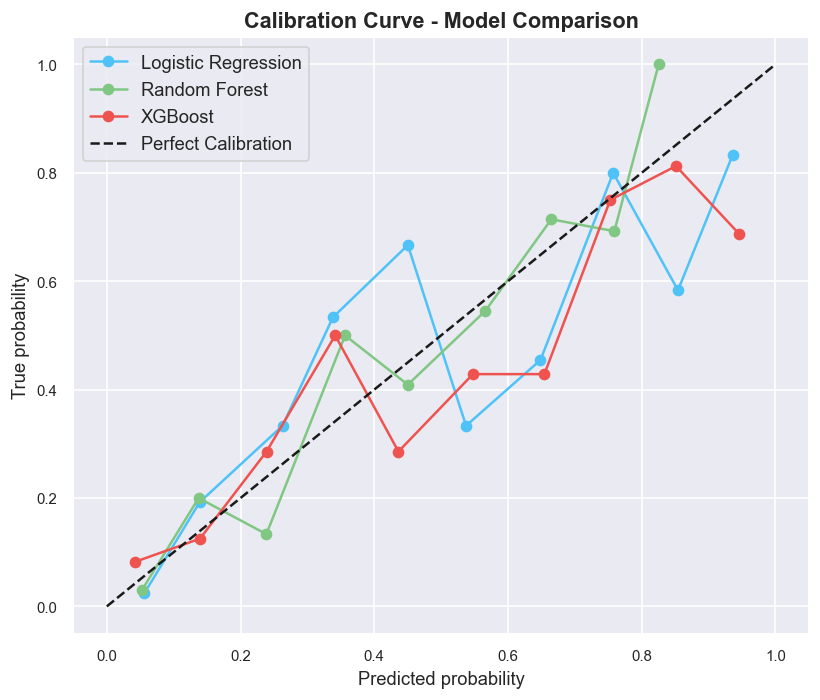

In [113]:
#Calibration curve :
fig, ax = plt.subplots(figsize=(7,6))

calibration_data = [
    ('Logistic Regression', lr_probas,  '#4fc3f7'),
    ('Random Forest',       rf_probas,  '#81c784'),
    ('XGBoost',             xgb_probas, '#ef5350'),
]

for name, probas, color in calibration_data:
    prob_true, prob_pred = calibration_curve(y_test, probas, n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', label=name, color=color)

ax.plot([0,1],[0,1],'k--', label='Perfect Calibration')

ax.set_xlabel("Predicted probability")
ax.set_ylabel("True probability")
ax.set_title("Calibration Curve - Model Comparison", fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

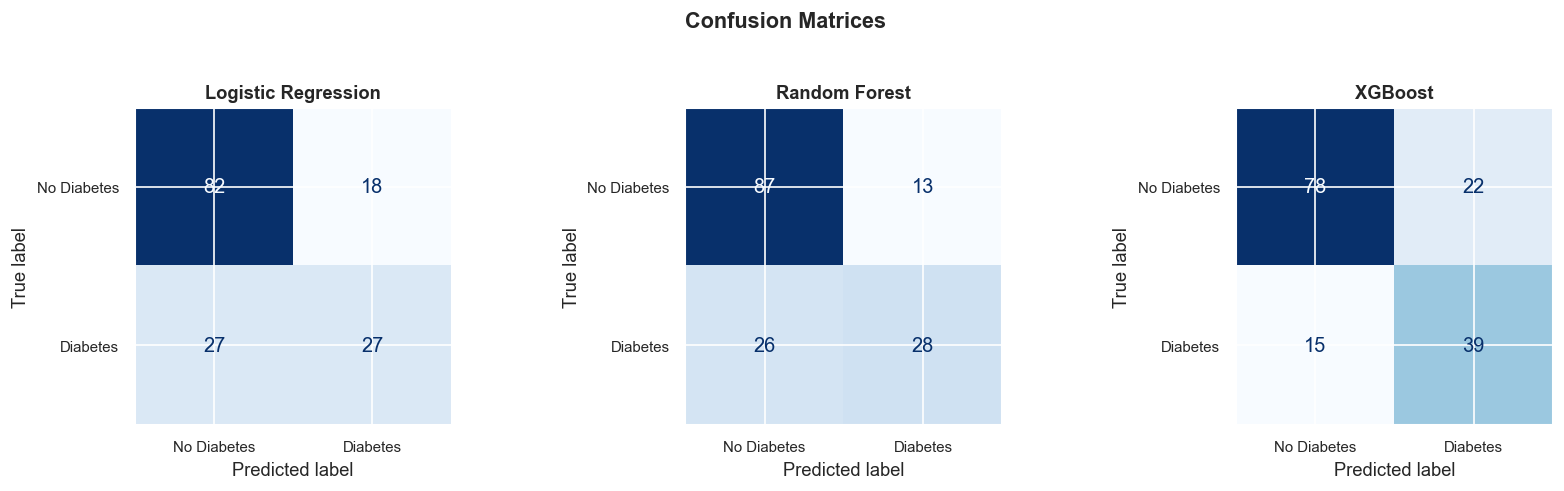

In [105]:
# Confusion matrices:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, model), preds in zip(
    axes,
    models,
    [lr_preds, rf_preds, xgb_preds]
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Diabetes', 'Diabetes']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

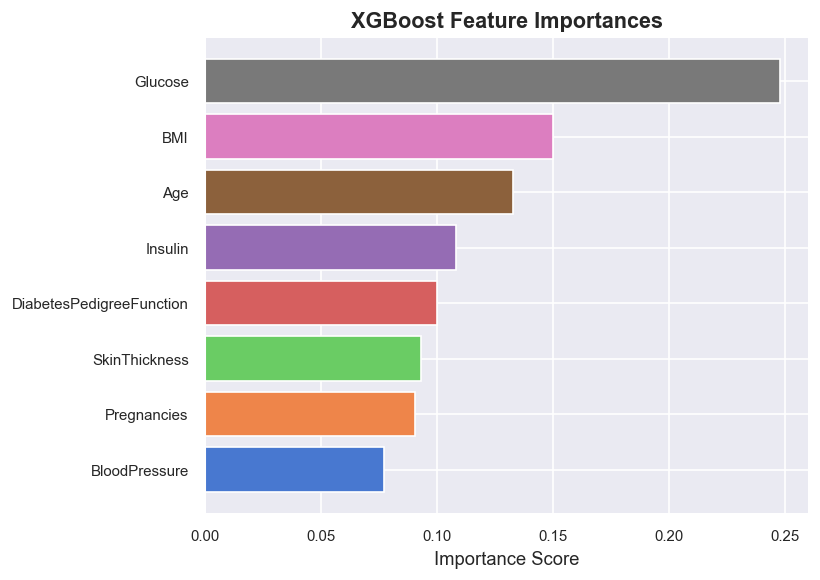


Feature importances (descending):
  Glucose                       0.2477
  BMI                           0.1502
  Age                           0.1328
  Insulin                       0.1082
  DiabetesPedigreeFunction      0.1002
  SkinThickness                 0.0932
  Pregnancies                   0.0904
  BloodPressure                 0.0774


In [114]:
# Feature Importance (XGBoost) :
xgb_clf = xgb_pipeline.named_steps['classifier']
importances = xgb_clf.feature_importances_

fi_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(
    fi_df['Feature'],
    fi_df['Importance'],
    color=sns.color_palette('muted', len(FEATURE_COLS))
)
ax.set_title('XGBoost Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nFeature importances (descending):')
for _, row in fi_df.sort_values('Importance', ascending=False).iterrows():
    print(f'  {row["Feature"]:28s}  {row["Importance"]:.4f}')

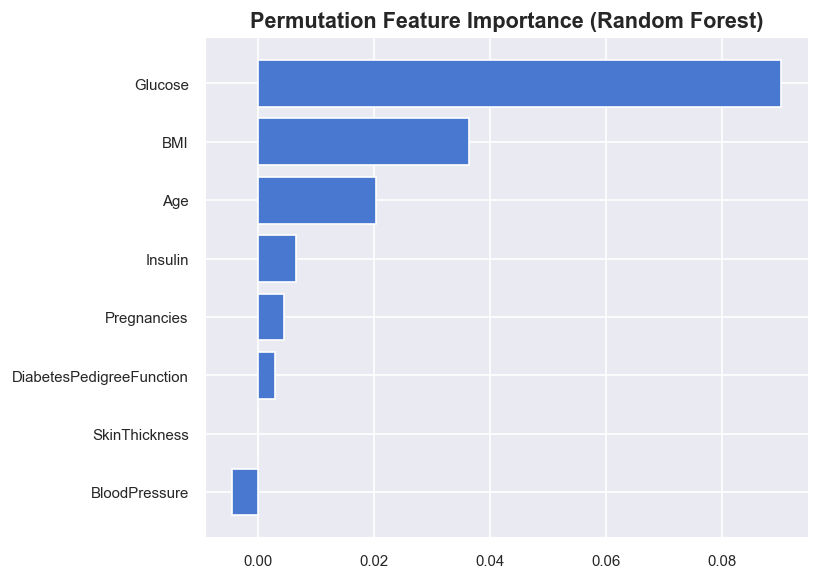

In [115]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": result.importances_mean
}).sort_values("Importance")

fig, ax = plt.subplots(figsize=(7,5))
ax.barh(perm_df["Feature"], perm_df["Importance"])
ax.set_title("Permutation Feature Importance (Random Forest)", fontweight="bold")

plt.tight_layout()
plt.show()

In [107]:
# Summary table :
summary = pd.DataFrame({
    'Model':    ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [f'{lr_acc:.4f}', f'{rf_acc:.4f}', f'{xgb_acc:.4f}'],
    'AUC-ROC':  [f'{lr_auc:.4f}', f'{rf_auc:.4f}', f'{xgb_auc:.4f}'],
    'CV AUC (mean ± std)': [
        f"{cv_results['Logistic Regression'].mean():.3f} +/- {cv_results['Logistic Regression'].std():.3f}",
        f"{cv_results['Random Forest'].mean():.3f} +/- {cv_results['Random Forest'].std():.3f}",
        f"{cv_results['XGBoost'].mean():.3f} +/- {cv_results['XGBoost'].std():.3f}",
    ]
})

print('Model Comparison Summary :')
print(summary.to_string(index=False))
print()

# Select best model by CV AUC
cv_means = {
    'Logistic Regression': cv_results['Logistic Regression'].mean(),
    'Random Forest':       cv_results['Random Forest'].mean(),
    'XGBoost':             cv_results['XGBoost'].mean(),
}
best_name = max(cv_means, key=cv_means.get)
print(f' Best model: {best_name}  (CV AUC = {cv_means[best_name]:.4f})')

Model Comparison Summary :
              Model Accuracy AUC-ROC CV AUC (mean ± std)
Logistic Regression   0.7078  0.8130     0.837 +/- 0.020
      Random Forest   0.7468  0.8085     0.840 +/- 0.020
            XGBoost   0.7597  0.8331     0.824 +/- 0.027

 Best model: Random Forest  (CV AUC = 0.8400)


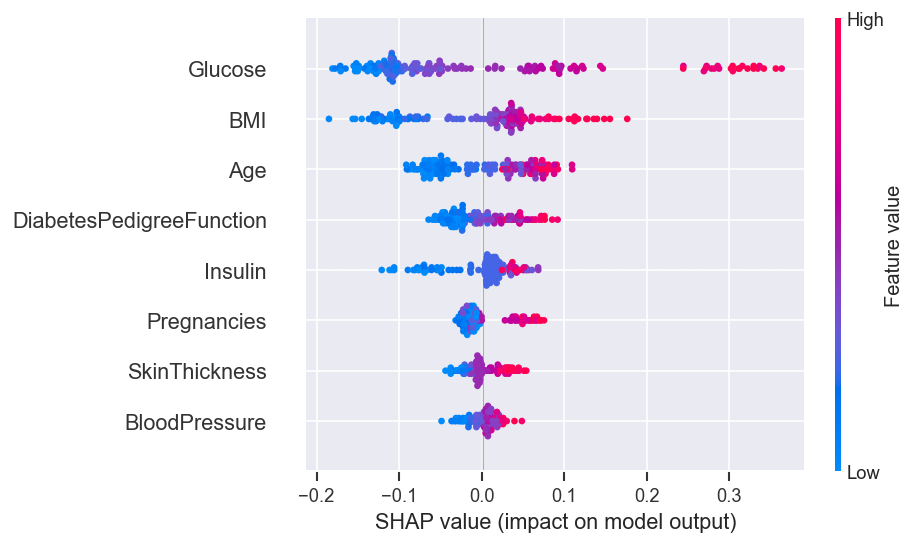

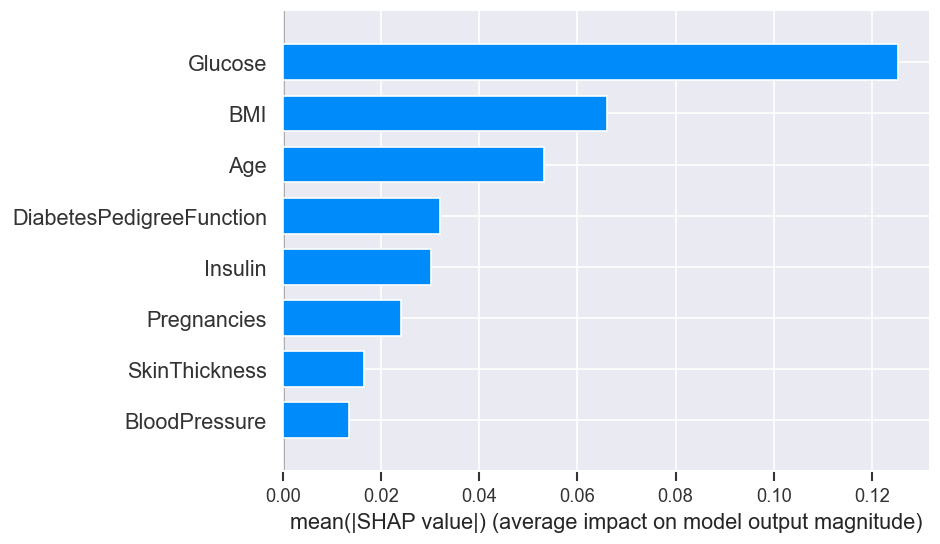

In [108]:
import shap
rf_model = rf_pipeline.named_steps['classifier']
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)
shap_vals_diabetes = shap_values[:, :, 1]
shap.summary_plot(shap_vals_diabetes, X_test)
shap.summary_plot(shap_vals_diabetes, X_test, plot_type="bar")

## 7. Save Best Model

In [109]:
# Select and save the best-performing pipeline :
# We save the entire sklearn Pipeline (scaler + classifier) so that
# the predict.py script can call .predict_proba() on raw input values
# without needing to replicate the scaling step.

# Map names to pipelines
pipeline_map = {
    'Logistic Regression': lr_pipeline,
    'Random Forest':       rf_pipeline,
    'XGBoost':             xgb_pipeline,
}

best_pipeline = pipeline_map[best_name]

# Output path (backend/models/ relative to the repo root)
MODEL_OUTPUT_PATH = os.path.join('..', 'backend', 'models', 'diabetes_model.pkl')

os.makedirs(os.path.dirname(MODEL_OUTPUT_PATH), exist_ok=True)

joblib.dump(best_pipeline, MODEL_OUTPUT_PATH)

print(f'Model saved to: {os.path.abspath(MODEL_OUTPUT_PATH)}')
print(f'Model type    : {type(best_pipeline)}')
print(f'Pipeline steps: {[step[0] for step in best_pipeline.steps]}')

Model saved to: /Users/soumyadeep/backend/models/diabetes_model.pkl
Model type    : <class 'sklearn.pipeline.Pipeline'>
Pipeline steps: ['classifier']


In [110]:
# Verify saved model:
# and reload the .pkl and make sure it produces the same predictions.

loaded_model = joblib.load(MODEL_OUTPUT_PATH)

# Test with first 5 test samples
sample_X = X_test.head(5)
original_probas = best_pipeline.predict_proba(sample_X)[:, 1]
reloaded_probas = loaded_model.predict_proba(sample_X)[:, 1]

print('Verification: original vs reloaded probabilities')
for orig, rel in zip(original_probas, reloaded_probas):
    match = 'matched' if abs(orig - rel) < 1e-9 else 'not matched'
    print(f'  {match}  original={orig:.6f}  reloaded={rel:.6f}')

print('\n  Model saved and verified successfully.')
print('  The backend predict.py script will load this file automatically.')

Verification: original vs reloaded probabilities
  matched  original=0.644241  reloaded=0.644241
  matched  original=0.219922  reloaded=0.219922
  matched  original=0.205980  reloaded=0.205980
  matched  original=0.305499  reloaded=0.305499
  matched  original=0.101649  reloaded=0.101649

  Model saved and verified successfully.
  The backend predict.py script will load this file automatically.


In [96]:
# Demo: prediction about a single patient 
# This mimics exactly what predict.py does at runtime.

# Feature order: Pregnancies, Glucose, BP, SkinThick, Insulin, BMI, DPF, Age
sample_patient = np.array([[6, 148, 72, 35, 0, 33.6, 0.627, 50]])

prob = loaded_model.predict_proba(sample_patient)[0][1]

def classify(p):
    if p < 0.30:  return 'Low Risk'
    if p <= 0.70: return 'Medium Risk'
    return 'High Risk'

print('Demo patient (first row of original PIMA dataset):')
fields = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
          'Insulin','BMI','DiabetesPedigreeFunction','Age']
for f, v in zip(fields, sample_patient[0]):
    print(f'  {f:28s}: {v}')
print()
print(f'  Diabetes Probability : {prob:.4f} ({prob*100:.1f}%)')
print(f'  Risk Classification  : {classify(prob)}')
print(f'  (Actual label in dataset: 1 = Diabetic)')

Demo patient (first row of original PIMA dataset):
  Pregnancies                 : 6.0
  Glucose                     : 148.0
  BloodPressure               : 72.0
  SkinThickness               : 35.0
  Insulin                     : 0.0
  BMI                         : 33.6
  DiabetesPedigreeFunction    : 0.627
  Age                         : 50.0

  Diabetes Probability : 0.4440 (44.4%)
  Risk Classification  : Medium Risk
  (Actual label in dataset: 1 = Diabetic)
